In [1]:
from utils import *
import seaborn as sns

In [2]:
experiments = [
    Experiment.basic_zero_plus_discr,
    Experiment.bell_state_reach,
    Experiment.bitflip_ipma,
    Experiment.reset,
    Experiment.ghz3
]

In [3]:
dfs = []
for experiment in experiments:
    path = get_paper_verification_path(experiment)
    df = pd.read_csv(path) # pyright: ignore
    df["experiment"] = get_nice_name(experiment)
    dfs.append(df) # pyright: ignore
    
df = pd.concat(dfs, ignore_index=True) # pyright: ignore
df
    

,hardware,embedding_index,horizon,method,time,result,experiment
0,algiers,0,1,convex,0.03990,1,state discr.
1,algiers,0,2,convex,0.00521,1,state discr.
2,algiers,0,3,convex,0.00983,1,state discr.
3,algiers,1,1,convex,0.00265,1,state discr.
4,algiers,1,2,convex,0.00539,1,state discr.
...,...,...,...,...,...,...,...
4235,quito,3,3,bellman,0.00679,1,GHZ
4236,valencia,0,3,bellman,0.00628,1,GHZ
4237,valencia,1,3,bellman,0.00666,1,GHZ
4238,valencia,2,3,bellman,0.00655,1,GHZ


In [4]:
df.describe()

,embedding_index,horizon,time,result
count,4240.000000,4240.000000,4240.000000,4240.0
mean,10.288915,3.500000,0.019393,1.0
std,25.798679,1.921311,0.026809,0.0
min,0.000000,1.000000,0.000850,1.0
25%,0.000000,2.000000,0.006210,1.0
50%,1.000000,3.000000,0.012680,1.0
75%,4.000000,4.000000,0.022960,1.0
max,190.000000,9.000000,0.694300,1.0


In [5]:
bellman_df = df[df.method == "bellman"]
bellman_df


,hardware,embedding_index,horizon,method,time,result,experiment
327,algiers,0,1,bellman,0.03456,1,Bell state reach
329,algiers,0,2,bellman,0.00971,1,Bell state reach
331,algiers,0,3,bellman,0.01518,1,Bell state reach
333,algiers,1,1,bellman,0.00781,1,Bell state reach
335,algiers,1,2,bellman,0.01530,1,Bell state reach
...,...,...,...,...,...,...,...
4235,quito,3,3,bellman,0.00679,1,GHZ
4236,valencia,0,3,bellman,0.00628,1,GHZ
4237,valencia,1,3,bellman,0.00666,1,GHZ
4238,valencia,2,3,bellman,0.00655,1,GHZ


In [6]:
convex_df = df[df.method == "convex"]
convex_df

,hardware,embedding_index,horizon,method,time,result,experiment
0,algiers,0,1,convex,0.03990,1,state discr.
1,algiers,0,2,convex,0.00521,1,state discr.
2,algiers,0,3,convex,0.00983,1,state discr.
3,algiers,1,1,convex,0.00265,1,state discr.
4,algiers,1,2,convex,0.00539,1,state discr.
...,...,...,...,...,...,...,...
2824,yorktown,1,2,convex,0.00296,1,Reset
2825,yorktown,1,3,convex,0.00586,1,Reset
2826,perfect_hardware,0,1,convex,0.00192,1,Reset
2827,perfect_hardware,0,2,convex,0.00103,1,Reset


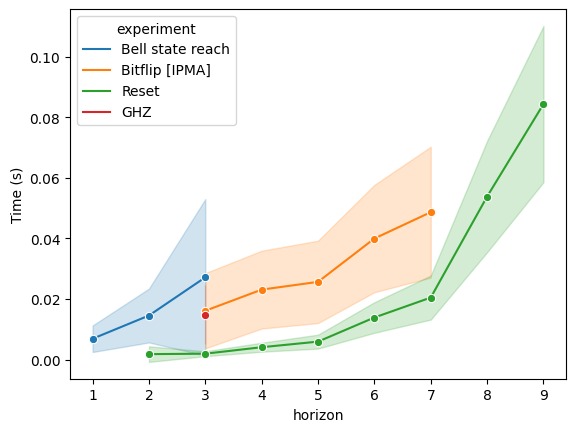

In [16]:
ax = sns.lineplot(bellman_df, x="horizon", y="time", hue="experiment", errorbar="sd", marker="o")
ax.set_ylabel("Time (s)")
plt.savefig("bellman_verify.pdf")

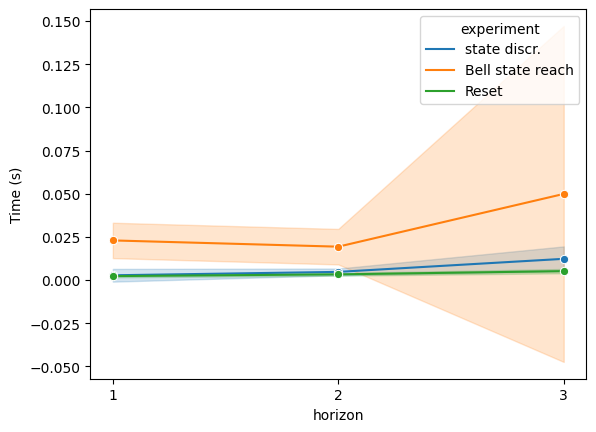

In [17]:
import matplotlib.pyplot as plt
ax = sns.lineplot(convex_df, x="horizon", y="time", hue="experiment", errorbar="sd", marker="o")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_ylabel("Time (s)")
plt.savefig("convex_verify.pdf")